In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set(style='whitegrid')

In [7]:
data = pd.read_csv('../Dataset/student_habits_performance.csv')

In [8]:
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

Missing value rows in dataset

In [10]:
data.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [11]:
data = data.dropna()

After removing the missing rows

In [12]:
data.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [13]:
data.shape

(909, 16)

col = 16 , row = 909

To check the duplicated records

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [17]:
data.describe(include='object')

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1000,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [18]:
categorical_col = ["gender","parental_education_level","diet_quality","part_time_job","internet_quality","extracurricular_participation"]

In [19]:
for col in categorical_col:
    print(f"values_counts for {col}: \n {data[col].value_counts()}")

values_counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
values_counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
values_counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
values_counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
values_counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
values_counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


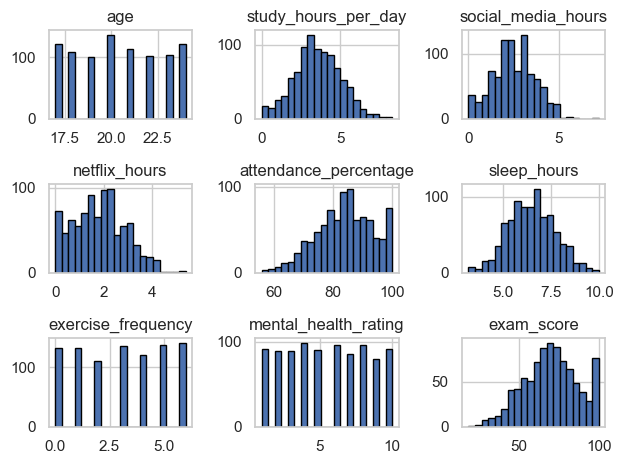

In [20]:
data.hist(bins=20,edgecolor='black')
plt.tight_layout()
plt.show()

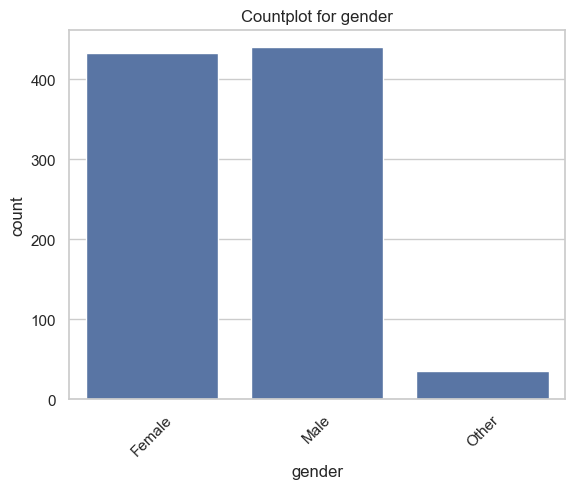

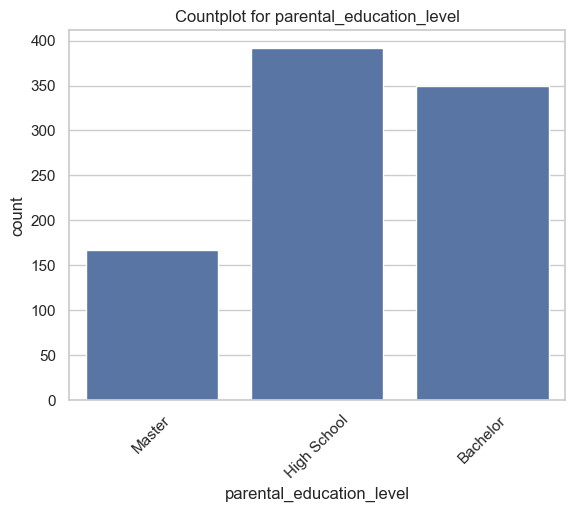

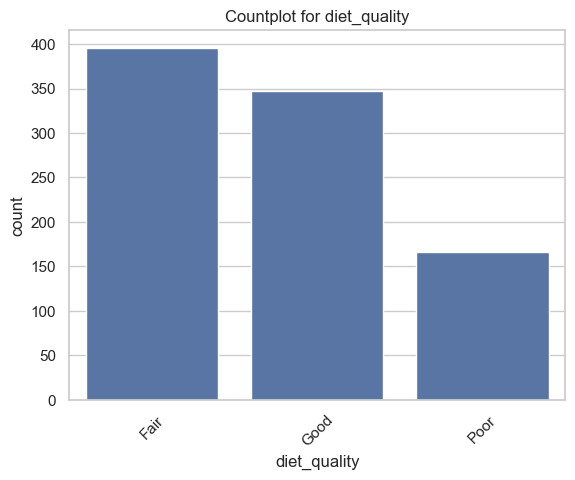

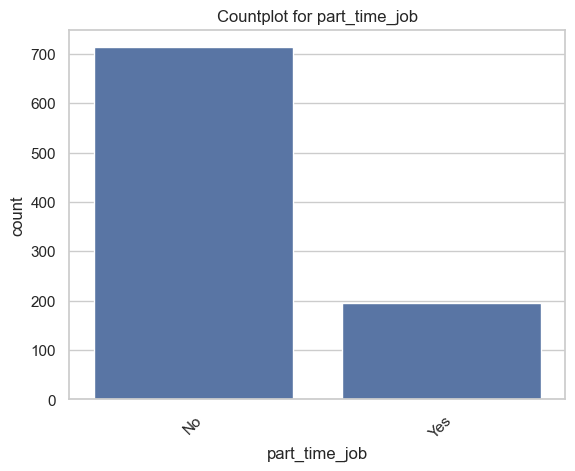

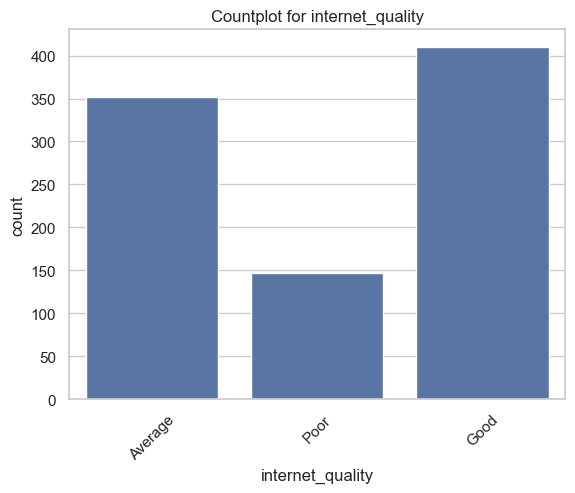

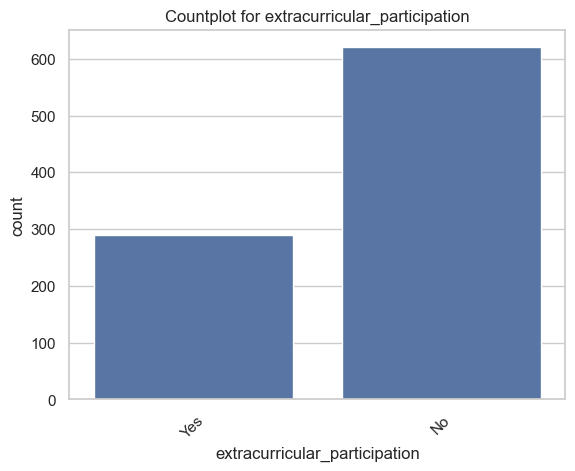

In [21]:
for col in categorical_col:
    sns.countplot(data=data,x=col)
    plt.title(f"Countplot for {col}")
    plt.xticks(rotation=45)
    plt.show()


In [22]:
data.corr(numeric_only=True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.007150,-0.023854,0.005841,-0.030203,0.040498,-0.005718,-0.052137,-0.012833
study_hours_per_day,0.007150,1.000000,0.007364,-0.014493,0.028967,-0.026241,-0.024708,-0.015896,0.822950
social_media_hours,-0.023854,0.007364,1.000000,0.011865,0.049356,0.026861,-0.023975,-0.000417,-0.171672
netflix_hours,0.005841,-0.014493,0.011865,1.000000,-0.015008,-0.017006,-0.004155,-0.016612,-0.166578
attendance_percentage,-0.030203,0.028967,0.049356,-0.015008,1.000000,0.001972,-0.010563,-0.017096,0.096005
sleep_hours,0.040498,-0.026241,0.026861,-0.017006,0.001972,1.000000,0.030013,-0.010653,0.122294
exercise_frequency,-0.005718,-0.024708,-0.023975,-0.004155,-0.010563,0.030013,1.000000,-0.001500,0.161397
mental_health_rating,-0.052137,-0.015896,-0.000417,-0.016612,-0.017096,-0.010653,-0.001500,1.000000,0.317945
exam_score,-0.012833,0.822950,-0.171672,-0.166578,0.096005,0.122294,0.161397,0.317945,1.000000


<Axes: >

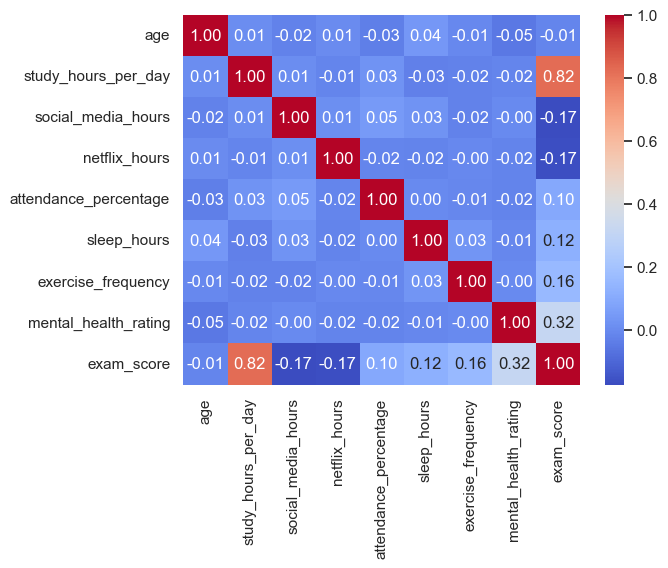

In [23]:
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt=".2f")

Taking the col which is required for learning.

if corr +ve then posituve correlation, one goes up - another also goes up. negative is opposite of positive correlation.


In [24]:
data.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [25]:
new_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score']

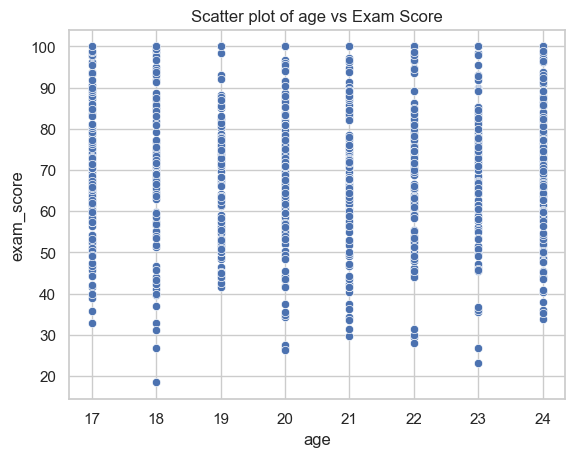

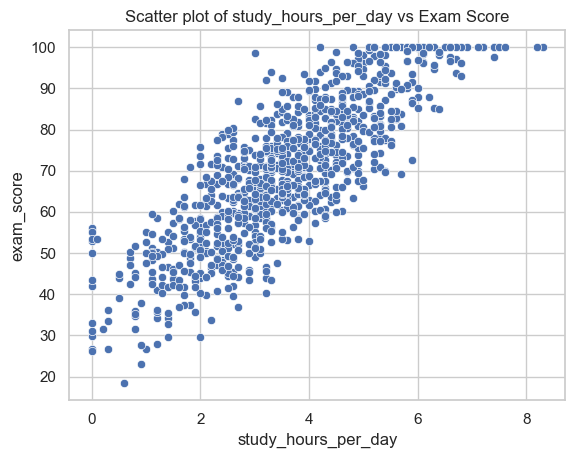

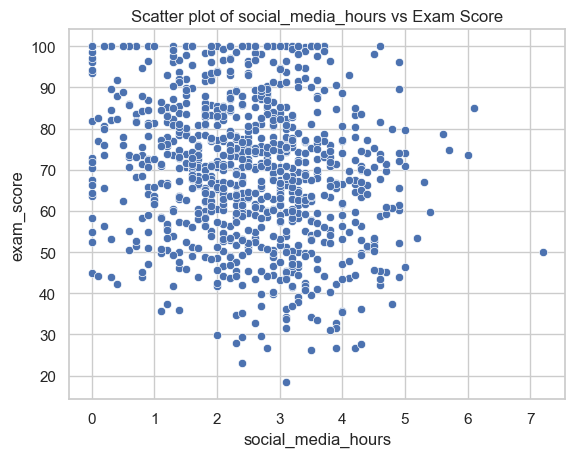

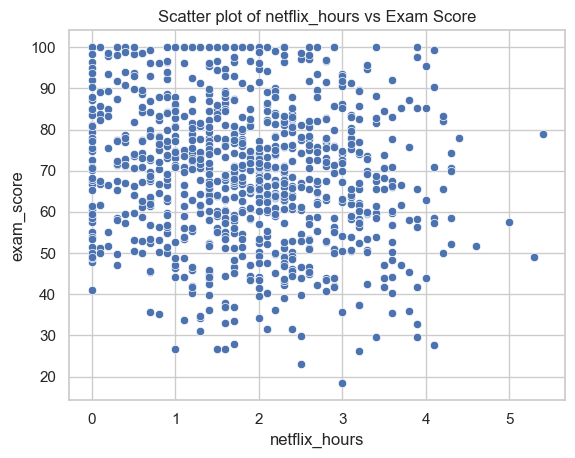

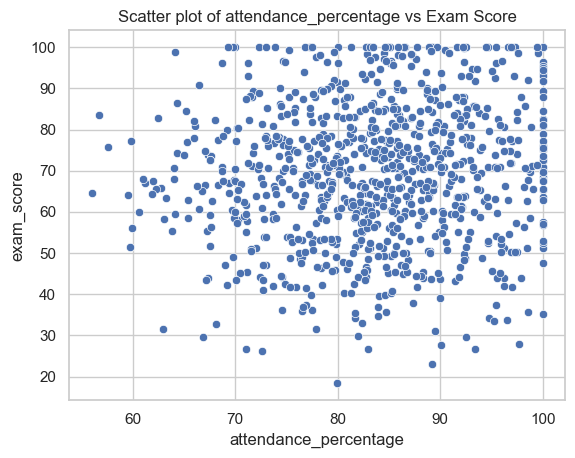

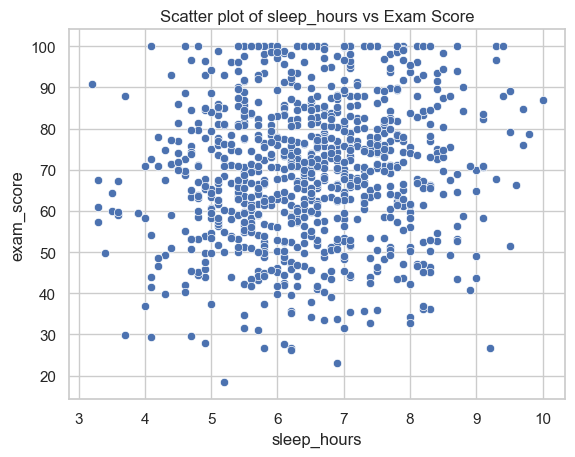

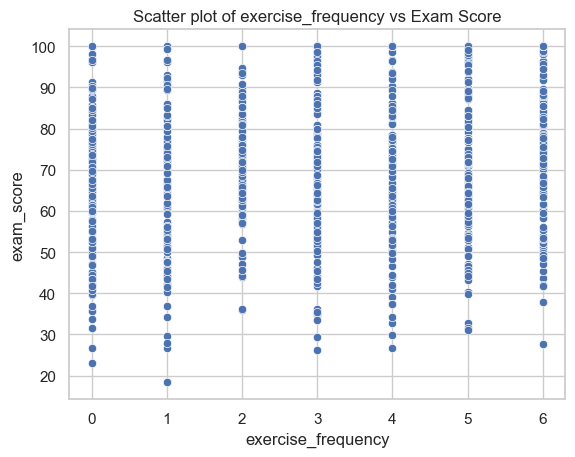

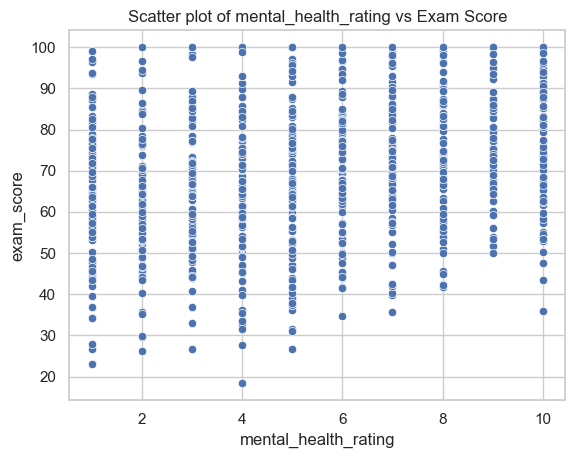

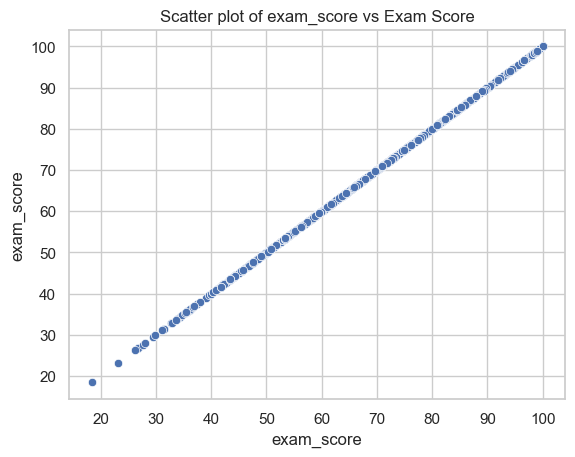

In [26]:
for feature in new_features:
    sns.scatterplot(data=data,x=feature,y='exam_score')
    plt.title(f"Scatter plot of {feature} vs Exam Score")
    plt.show()

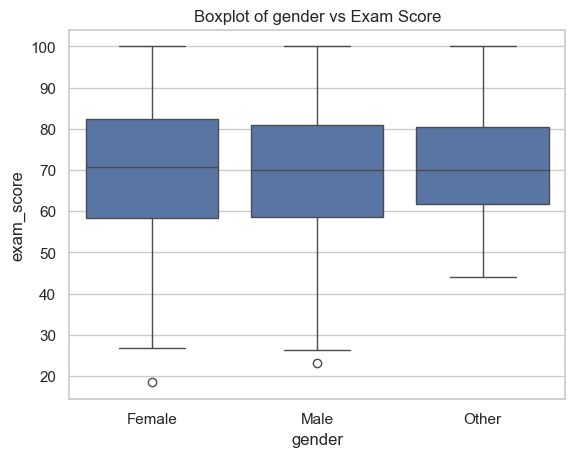

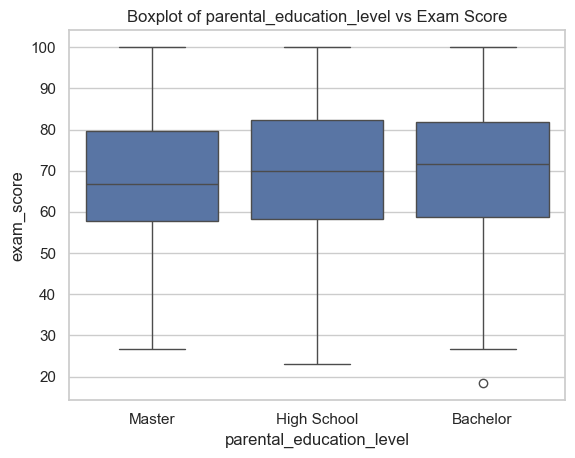

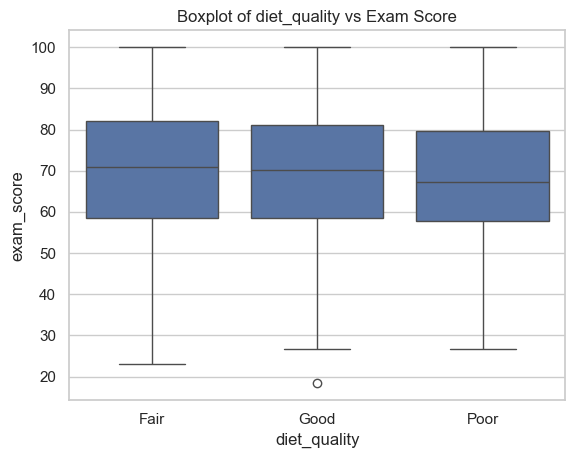

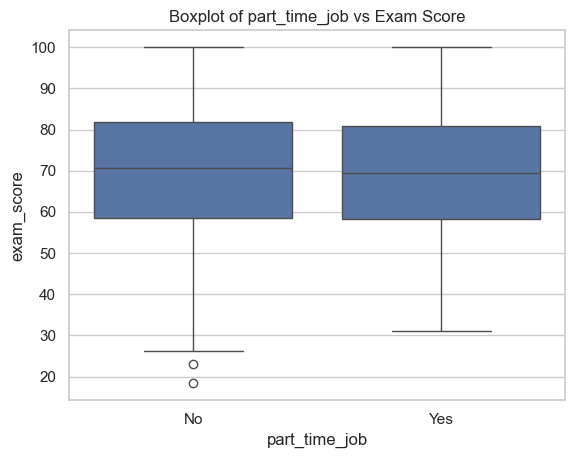

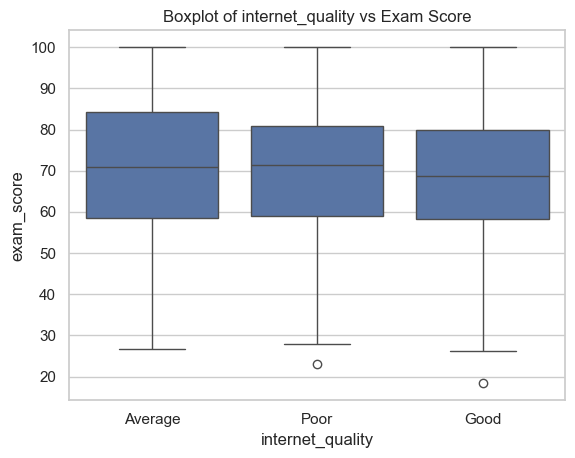

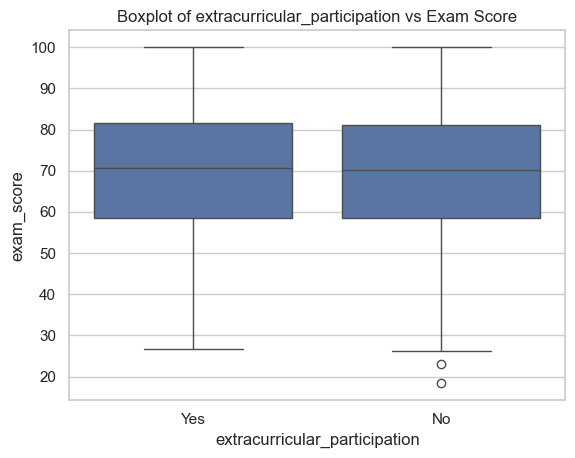

In [27]:
for col in categorical_col:
    sns.boxplot(data=data,x=col,y='exam_score')
    plt.title(f"Boxplot of {col} vs Exam Score")
    plt.show()

Feature Engineering

In [28]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [29]:
data.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [30]:
req_col = ['study_hours_per_day','attendance_percentage','mental_health_rating','sleep_hours','part_time_job']

In [31]:
target_col = 'exam_score'

In [32]:
data_model = data[req_col + [target_col]].copy()
data_model.head()

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4


Coverting all the features in terms of numericals.

In [33]:
le = LabelEncoder()

In [34]:
data_model['part_time_job'] = le.fit_transform(data_model['part_time_job'])
data_model.head()


,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4


In [35]:
x = data_model[req_col]
y = data_model[target_col]

In [36]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [37]:
len(y_train)

727

In [38]:
len(y_test)

182

In [39]:
models = {
    "LinearRegression":
    {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree":{
        "model": DecisionTreeRegressor(),
        "params": {
            "max_depth":[3,5,10],
            "min_samples_split":[2,5]
        }
    },
    "randomForest":{
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators":[50,100],
            "max_depth":[5,10]
        }
    }
}

In [40]:
best_model = []

In [41]:
for name,comfig in models.items():
    print(f"Training {name}...")

    grid = GridSearchCV(comfig['model'],comfig['params'],cv=5,scoring='neg_mean_squared_error')
    grid.fit(X_train,y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)

    best_model.append({
        "model": name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "r2_score": r2
    })

Training LinearRegression...
Training DecisionTree...
Training randomForest...


In [42]:
best_model

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.275493648964052),
  'r2_score': 0.8151114405234724},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.355317855369584),
  'r2_score': 0.7561565697786187},
 {'model': 'randomForest',
  'best_params': {'max_depth': 5, 'n_estimators': 100},
  'rmse': np.float64(7.513429565212224),
  'r2_score': 0.8028205977167542}]

converting to dataframe

In [43]:
results_df = pd.DataFrame(best_model)

In [44]:
results_df.sort_values(by='rmse')

,model,best_params,rmse,r2_score
0,LinearRegression,{},7.275494,0.815111
2,randomForest,"{'max_depth': 5, 'n_estimators': 100}",7.513430,0.802821
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.355318,0.756157


In [45]:
import joblib

bestrow = results_df.sort_values(by='rmse').iloc[0]

In [46]:
bestrow

model          LinearRegression
best_params                  {}
rmse                   7.275494
r2_score               0.815111
Name: 0, dtype: object

In [49]:
best_model_name = bestrow['model']
best_model_name

'LinearRegression'

In [51]:
best_config = models[best_model_name]
best_config

{'model': LinearRegression(), 'params': {}}

In [52]:
final_model = best_config['model']

In [53]:
final_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
joblib.dump(final_model,'best_model.pkl')

['best_model.pkl']

In [56]:
joblib.load("best_model.pkl").predict(X_test)

array([ 57.45957817,  70.64707086,  45.36227919,  62.79878985,
        69.18028217,  57.45595147,  43.14340981,  94.26716699,
        82.27551134,  56.40314637,  65.24574029,  64.22442454,
       104.58685302,  99.00015462,  67.22882072,  57.75569122,
        71.62634586,  93.907731  ,  47.41966756,  56.50647088,
        77.26666279,  76.90551635,  81.39667248,  48.21064224,
        69.37049503,  56.51857377,  66.5155005 ,  84.20309395,
        64.7719743 ,  99.38541188,  78.99961143,  89.1592608 ,
        56.52867139,  73.33758565,  69.29900088,  73.3095103 ,
        60.78719557,  74.55553431,  61.0234794 ,  86.35977735,
        52.07971586,  60.44639729,  93.29678994,  65.13307337,
        95.61742841,  50.4895758 ,  40.0082463 ,  60.37009385,
        56.25121079,  85.05249299,  61.28183191,  82.07659987,
        69.09467311,  78.70663792,  48.67726609,  60.18318046,
        70.19382401,  69.35389946,  79.7157785 ,  73.87388264,
        82.16654734,  55.66431716,  59.41323383,  53.62